# Analysis of the score data

### Summary: Local Geometry at a Point $x$

Let $\mathcal{C} \subset \mathbb{R}^d$ be the true data manifold and $\mathcal{M}_\sigma \subset \mathbb{R}^d$ the mode manifold of $p_\sigma$.

**Score.**
$$s(x) = \nabla_x \log p_\sigma(x) = \frac{\mathbb{E}_{y \sim p_\sigma(y|x)}[y] - x}{\sigma^2} \in \mathbb{R}^d$$

**Jacobian of the score (Hessian of log-density).**
$$J(x) = \nabla_x s(x) = \nabla_x^2 \log p_\sigma(x) = \frac{1}{\sigma^4}\operatorname{Cov}_{p_\sigma(y|x)}(y) - \frac{1}{\sigma^2}I_d$$

$J(x)$ is symmetric negative semi-definite. Its eigen-decomposition $J(x) = \sum_i \lambda_i v_i v_i^\top$ yields:
- **Eigenvectors** $v_i(x) \in \mathbb{R}^d$: principal curvature directions of $\log p_\sigma$ at $x$.
- **Eigenvalues** $\lambda_i(x) \leq 0$: the most negative eigenvalue corresponds to the direction of steepest log-density curvature (normal to the manifold); the least negative corresponds to the tangential direction.

**Projection onto the true manifold.**
$$\pi_0(x) = \operatorname{argmin}_{z \in \mathcal{C}} \|x - z\|$$

The vector $x - \pi_0(x)$ lies in the normal space of $\mathcal{C}$ at $\pi_0(x)$ (when $x$ is within the reach of $\mathcal{C}$).

**Projection onto the mode manifold.**
$$\pi_\sigma(x) = \operatorname{argmin}_{z \in \mathcal{M}_\sigma} \|x - z\|$$

$\mathcal{M}_\sigma$ is the set of local maxima of $p_\sigma$ along every normal direction; equivalently, $s(z) = 0$ on $\mathcal{M}_\sigma$. As $\sigma \to 0$, $\mathcal{M}_\sigma \to \mathcal{C}$ and $\pi_\sigma(x) \to 
\pi_0(x)$.

For a given point x we have

$\kappa_{\text{proj\_true}}(x) = \kappa(\pi_0(x))$

$\kappa_{\text{proj\_mode}}(x) = \kappa(\pi_\sigma(x))$

The following variables depend only on the manifold not on x or its sampling.
kappa_max_true, 
kappa_mean_true, 
kappa_min_true, 
kappa_max_mode, 
kappa_mean_mode, 
kappa_min_mode, 


In [8]:
import pandas as pd
import numpy as np

df = pd.read_parquet('../experiments/data/score_properties_sweep.parquet')
print(df.shape)
print(df.dtypes)
df.head()


(26460, 34)
x                   float64
y                   float64
a                     int64
b                   float64
sigma               float64
phase               float64
score_x             float64
score_y             float64
eigval_0            float64
eigval_1            float64
eigvec_00           float64
eigvec_01           float64
eigvec_10           float64
eigvec_11           float64
eigvec_scaled_00    float64
eigvec_scaled_01    float64
eigvec_scaled_10    float64
eigvec_scaled_11    float64
proj_true_x         float64
proj_true_y         float64
proj_mode_x         float64
proj_mode_y         float64
proj_true_vec_x     float64
proj_true_vec_y     float64
proj_mode_vec_x     float64
proj_mode_vec_y     float64
kappa_max_true      float64
kappa_mean_true     float64
kappa_min_true      float64
kappa_max_mode      float64
kappa_mean_mode     float64
kappa_min_mode      float64
kappa_proj_true     float64
kappa_proj_mode     float64
dtype: object


,x,y,a,b,sigma,phase,score_x,score_y,eigval_0,eigval_1,...,proj_mode_vec_x,proj_mode_vec_y,kappa_max_true,kappa_mean_true,kappa_min_true,kappa_max_mode,kappa_mean_mode,kappa_min_mode,kappa_proj_true,kappa_proj_mode
0,-2.0,-2.0,4,0.5,0.02,0.0,NaN,NaN,NaN,NaN,...,1.096227,1.395733,2.469136,1.33331,0.000065,2.45574,1.322384,0.000893,1.979910,1.978261
1,-2.0,-1.8,4,0.5,0.02,0.0,NaN,NaN,NaN,NaN,...,1.074258,1.214179,2.469136,1.33331,0.000065,2.45574,1.322384,0.000893,2.081397,2.078754
2,-2.0,-1.6,4,0.5,0.02,0.0,NaN,NaN,NaN,NaN,...,1.050974,1.036390,2.469136,1.33331,0.000065,2.45574,1.322384,0.000893,2.189139,2.182986
3,-2.0,-1.4,4,0.5,0.02,0.0,NaN,NaN,NaN,NaN,...,1.027086,0.862824,2.469136,1.33331,0.000065,2.45574,1.322384,0.000893,2.291622,2.284215
4,-2.0,-1.2,4,0.5,0.02,0.0,NaN,NaN,NaN,NaN,...,1.003471,0.693919,2.469136,1.33331,0.000065,2.45574,1.322384,0.000893,2.382797,2.373286


In [9]:
# Parameter ranges and NaN coverage
print("=== Parameter Ranges ===")
for col in ['a', 'b', 'sigma', 'phase']:
    vals = sorted(df[col].unique())
    print(f"{col}: {vals[:8]}{'...' if len(vals)>8 else ''} (n={len(vals)})")

print("\n=== NaN counts ===")
nan_cols = df.isna().sum()
print(nan_cols[nan_cols > 0])

print(f"\nTotal rows: {len(df)}")
print(f"Rows with any NaN in score/eigval: {df[['score_x','score_y','eigval_0','eigval_1']].isna().any(axis=1).sum()}")


=== Parameter Ranges ===
a: [np.int64(4), np.int64(8), np.int64(16), np.int64(32)] (n=4)
b: [np.float64(0.5), np.float64(1.0), np.float64(2.0)] (n=3)
sigma: [np.float64(0.02), np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.5)] (n=5)
phase: [np.float64(0.0)] (n=1)

=== NaN counts ===
score_x             2203
score_y             2203
eigval_0            2203
eigval_1            2203
eigvec_00           2203
eigvec_01           2203
eigvec_10           2203
eigvec_11           2203
eigvec_scaled_00    2203
eigvec_scaled_01    2203
eigvec_scaled_10    2203
eigvec_scaled_11    2203
dtype: int64

Total rows: 26460
Rows with any NaN in score/eigval: 2203


In [10]:
# Understand the grid structure and NaN pattern
valid = df.dropna(subset=['score_x'])
print("=== Grid structure ===")
print(f"Valid rows: {len(valid)} / {len(df)} ({100*len(valid)/len(df):.1f}%)")
print(f"\nRows per (a, b, sigma):")
print(df.groupby(['a','b','sigma']).size().unstack(['b','sigma']))

print(f"\nValid rows per (a, b, sigma):")
print(valid.groupby(['a','b','sigma']).size().unstack(['b','sigma']))


=== Grid structure ===
Valid rows: 24257 / 26460 (91.7%)

Rows per (a, b, sigma):
b      0.5                      1.0                      2.0                 \
sigma 0.02 0.05 0.10 0.20 0.50 0.02 0.05 0.10 0.20 0.50 0.02 0.05 0.10 0.20   
a                                                                             
4      441  441  441  441  441  441  441  441  441  441  441  441  441  441   
8      441  441  441  441  441  441  441  441  441  441  441  441  441  441   
16     441  441  441  441  441  441  441  441  441  441  441  441  441  441   
32     441  441  441  441  441  441  441  441  441  441  441  441  441  441   

b           
sigma 0.50  
a           
4      441  
8      441  
16     441  
32     441  

Valid rows per (a, b, sigma):
b      0.5                      1.0                      2.0                 \
sigma 0.02 0.05 0.10 0.20 0.50 0.02 0.05 0.10 0.20 0.50 0.02 0.05 0.10 0.20   
a                                                                             
4    

In [15]:
# Key stats on valid rows
v = df.dropna(subset=['score_x']).copy()
v['score_mag'] = np.sqrt(v['score_x']**2 + v['score_y']**2)
v['eigval_log_ratio'] = np.log(v['eigval_0'] / v['eigval_1'].replace(0, np.nan))

print("=== Score magnitude ===")
print(v.groupby('sigma')['score_mag'].describe().round(3))

print("\n=== Eigenvalue ratio (tangential/normal) by sigma ===")
print(v.groupby('sigma')['eigval_log_ratio'].describe().round(3))


=== Score magnitude ===
        count     mean      std  min      25%      50%       75%       max
sigma                                                                     
0.02   3089.0  875.281  540.380  0.0  388.159  849.221  1345.353  1858.838
0.05   5292.0  262.820  173.315  0.0  113.658  246.750   389.033   726.087
0.10   5292.0   65.976   43.313  0.0   27.956   62.148    97.729   181.801
0.20   5292.0   16.747   10.890  0.0    7.295   15.709    24.795    45.758
0.50   5292.0    2.891    1.858  0.0    1.223    2.862     4.287     7.492

=== Eigenvalue ratio (tangential/normal) by sigma ===
        count   mean    std    min    25%    50%    75%    max
sigma                                                         
0.02   2634.0  0.678  0.913 -5.760  0.143  0.379  0.842  5.910
0.05   4383.0  0.543  0.881 -3.439  0.099  0.263  0.611  8.774
0.10   4080.0  0.786  0.984 -3.164  0.198  0.448  1.017  7.876
0.20   4105.0  0.976  0.939 -1.621  0.399  0.680  1.183  7.733
0.50   4716.0  0.8

/Users/danielgagliardi/Documents/GitHub/Latent-Diffusion-Geometry/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


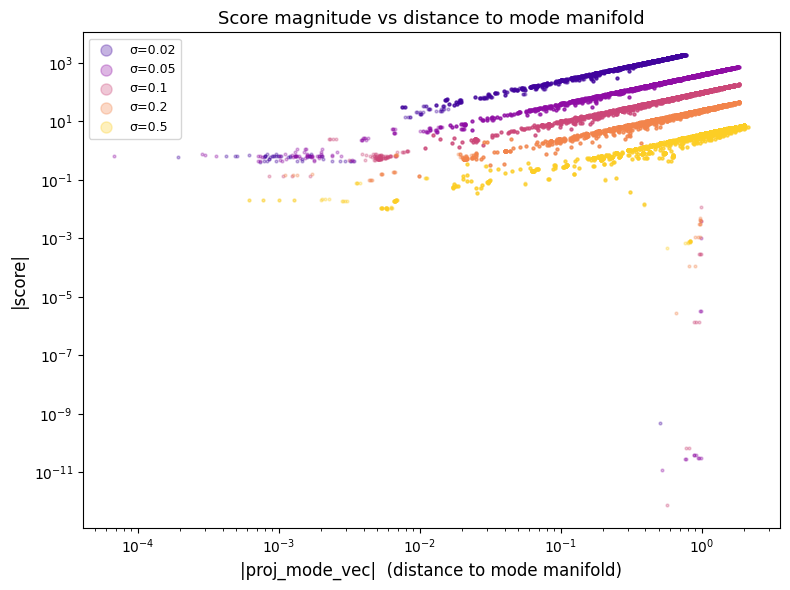

saved plots/10-score-vs-proj-mode.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

v = df.dropna(subset=['score_x']).copy()
v['score_mag'] = np.sqrt(v['score_x']**2 + v['score_y']**2)
v['proj_mode_mag'] = np.sqrt(v['proj_mode_vec_x']**2 + v['proj_mode_vec_y']**2)

# drop zero-mag entries (on-manifold)
v = v[(v['score_mag'] > 0) & (v['proj_mode_mag'] > 1e-8)]

sigmas = sorted(v['sigma'].unique())
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(sigmas)))

fig, ax = plt.subplots(figsize=(8, 6))

for sig, color in zip(sigmas, colors):
    sub = v[v['sigma'] == sig]
    ax.scatter(sub['proj_mode_mag'], sub['score_mag'],
               s=4, alpha=0.3, color=color, label=f'σ={sig}', rasterized=True)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('|proj_mode_vec|  (distance to mode manifold)', fontsize=12)
ax.set_ylabel('|score|', fontsize=12)
ax.set_title('Score magnitude vs distance to mode manifold', fontsize=13)
ax.legend(markerscale=4, fontsize=9)

plt.tight_layout()
plt.savefig('plots/10-score-vs-proj-mode.png', dpi=120, bbox_inches='tight')
plt.show()
print("saved plots/10-score-vs-proj-mode.png")


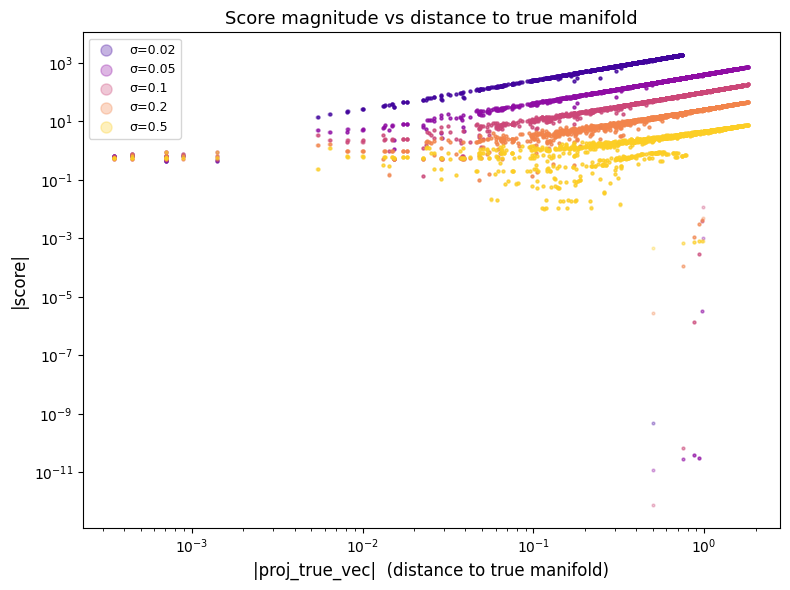

saved plots/10-score-vs-proj-true.png


In [ ]:
v2 = df.dropna(subset=['score_x']).copy()
v2['score_mag'] = np.sqrt(v2['score_x']**2 + v2['score_y']**2)
v2['proj_true_mag'] = np.sqrt(v2['proj_true_vec_x']**2 + v2['proj_true_vec_y']**2)

v2 = v2[(v2['score_mag'] > 0) & (v2['proj_true_mag'] > 1e-8)]

fig, ax = plt.subplots(figsize=(8, 6))

for sig, color in zip(sigmas, colors):
    sub = v2[v2['sigma'] == sig]
    ax.scatter(sub['proj_true_mag'], sub['score_mag'],
               s=4, alpha=0.3, color=color, label=f'σ={sig}', rasterized=True)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('|proj_true_vec|  (distance to true manifold)', fontsize=12)
ax.set_ylabel('|score|', fontsize=12)
ax.set_title('Score magnitude vs distance to true manifold', fontsize=13)
ax.legend(markerscale=4, fontsize=9)

plt.tight_layout()
plt.savefig('plots/10-score-vs-proj-true.png', dpi=120, bbox_inches='tight')
plt.show()
print("saved plots/10-score-vs-proj-true.png")


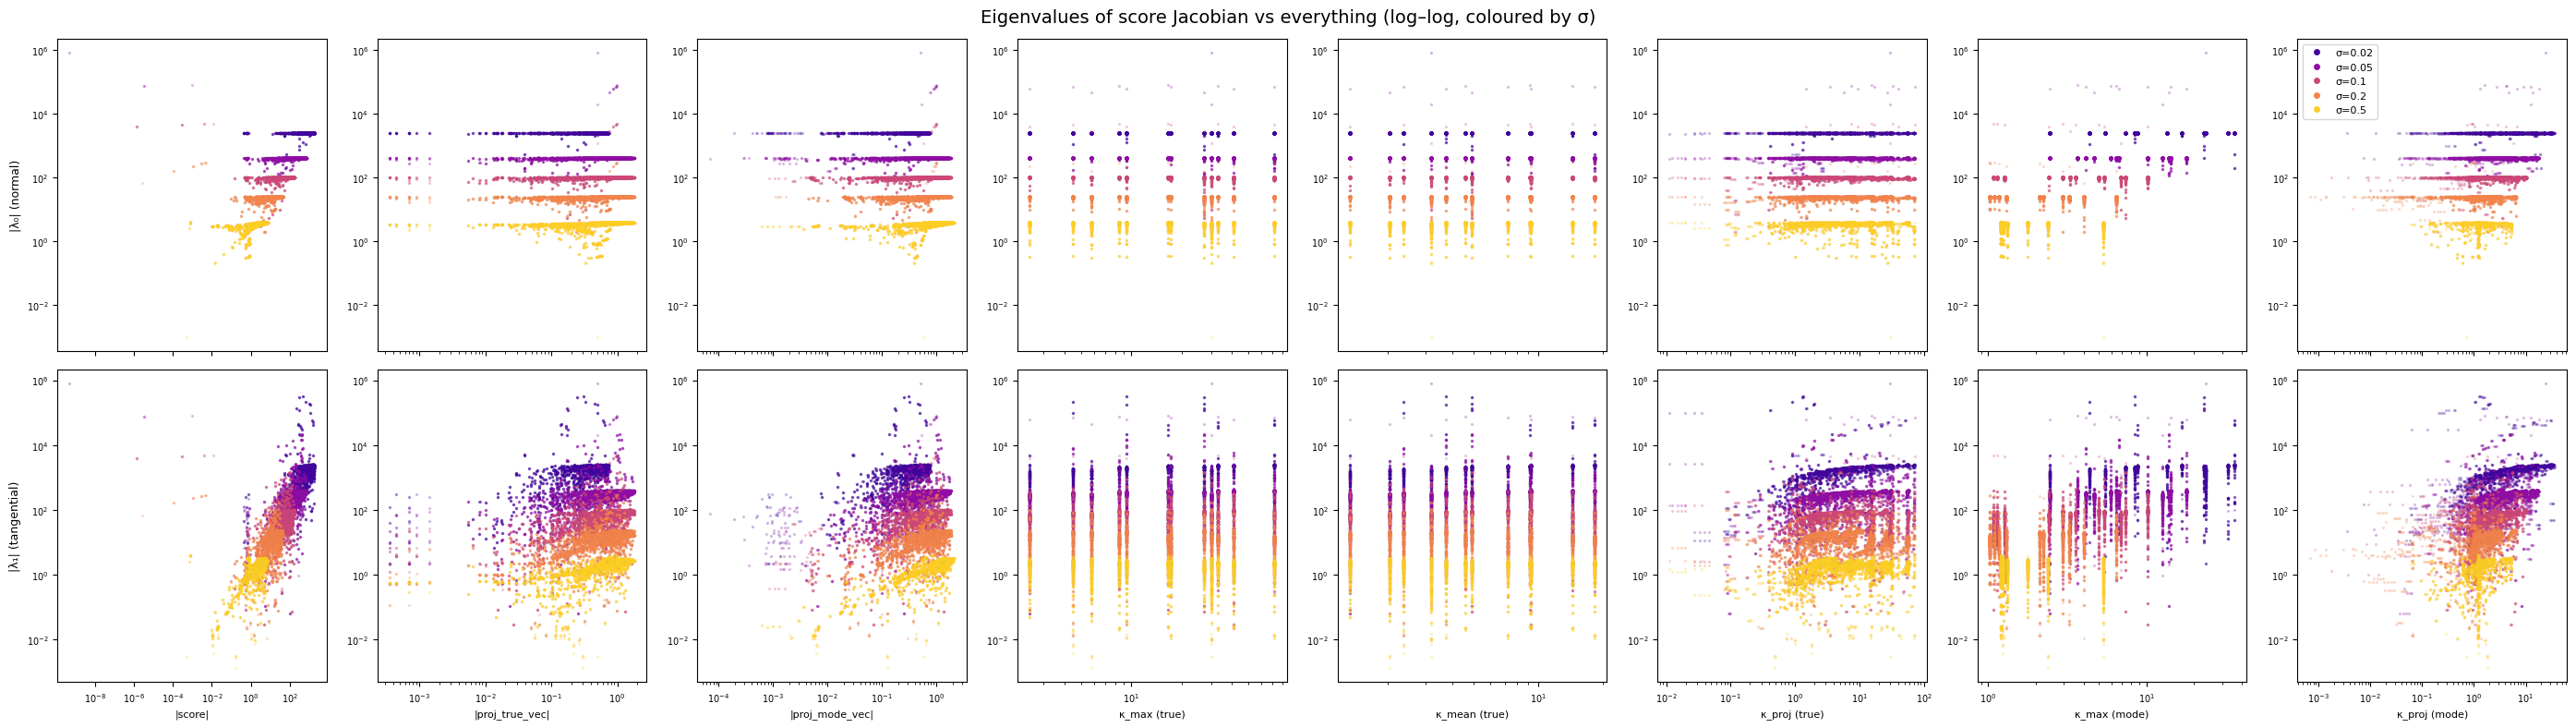

saved plots/10-eigenvalues-vs-all.png


In [ ]:
v = df.dropna(subset=['score_x']).copy()
v['score_mag']     = np.sqrt(v['score_x']**2 + v['score_y']**2)
v['proj_true_mag'] = np.sqrt(v['proj_true_vec_x']**2 + v['proj_true_vec_y']**2)
v['proj_mode_mag'] = np.sqrt(v['proj_mode_vec_x']**2 + v['proj_mode_vec_y']**2)
v['abs_eig0']      = v['eigval_0'].abs()   # most negative — normal dir
v['abs_eig1']      = v['eigval_1'].abs()   # least negative — tangential dir

x_cols = [
    ('score_mag',      '|score|'),
    ('proj_true_mag',  '|proj_true_vec|'),
    ('proj_mode_mag',  '|proj_mode_vec|'),
    ('kappa_max_true', 'κ_max (true)'),
    ('kappa_mean_true','κ_mean (true)'),
    ('kappa_proj_true','κ_proj (true)'),
    ('kappa_max_mode', 'κ_max (mode)'),
    ('kappa_proj_mode','κ_proj (mode)'),
]
y_rows = [
    ('abs_eig0', '|λ₀| (normal)'),
    ('abs_eig1', '|λ₁| (tangential)'),
]

sigmas = sorted(v['sigma'].unique())
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(sigmas)))
sig_color = dict(zip(sigmas, colors))

fig, axes = plt.subplots(2, 8, figsize=(28, 8), sharex='col')
fig.suptitle('Eigenvalues of score Jacobian vs everything (log–log, coloured by σ)', fontsize=14)

for row, (ycol, ylabel) in enumerate(y_rows):
    for col, (xcol, xlabel) in enumerate(x_cols):
        ax = axes[row, col]
        sub = v[(v[xcol] > 1e-10) & (v[ycol] > 1e-10)]
        for sig in sigmas:
            s = sub[sub['sigma'] == sig]
            ax.scatter(s[xcol], s[ycol], s=2, alpha=0.2,
                       color=sig_color[sig], rasterized=True)
        ax.set_xscale('log')
        ax.set_yscale('log')
        if row == 1:
            ax.set_xlabel(xlabel, fontsize=8)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        ax.tick_params(labelsize=7)

# legend on last axis
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=sig_color[s],
                  markersize=6, label=f'σ={s}') for s in sigmas]
axes[0, -1].legend(handles=handles, fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('plots/10-eigenvalues-vs-all.png', dpi=110, bbox_inches='tight')
plt.show()
print("saved plots/10-eigenvalues-vs-all.png")


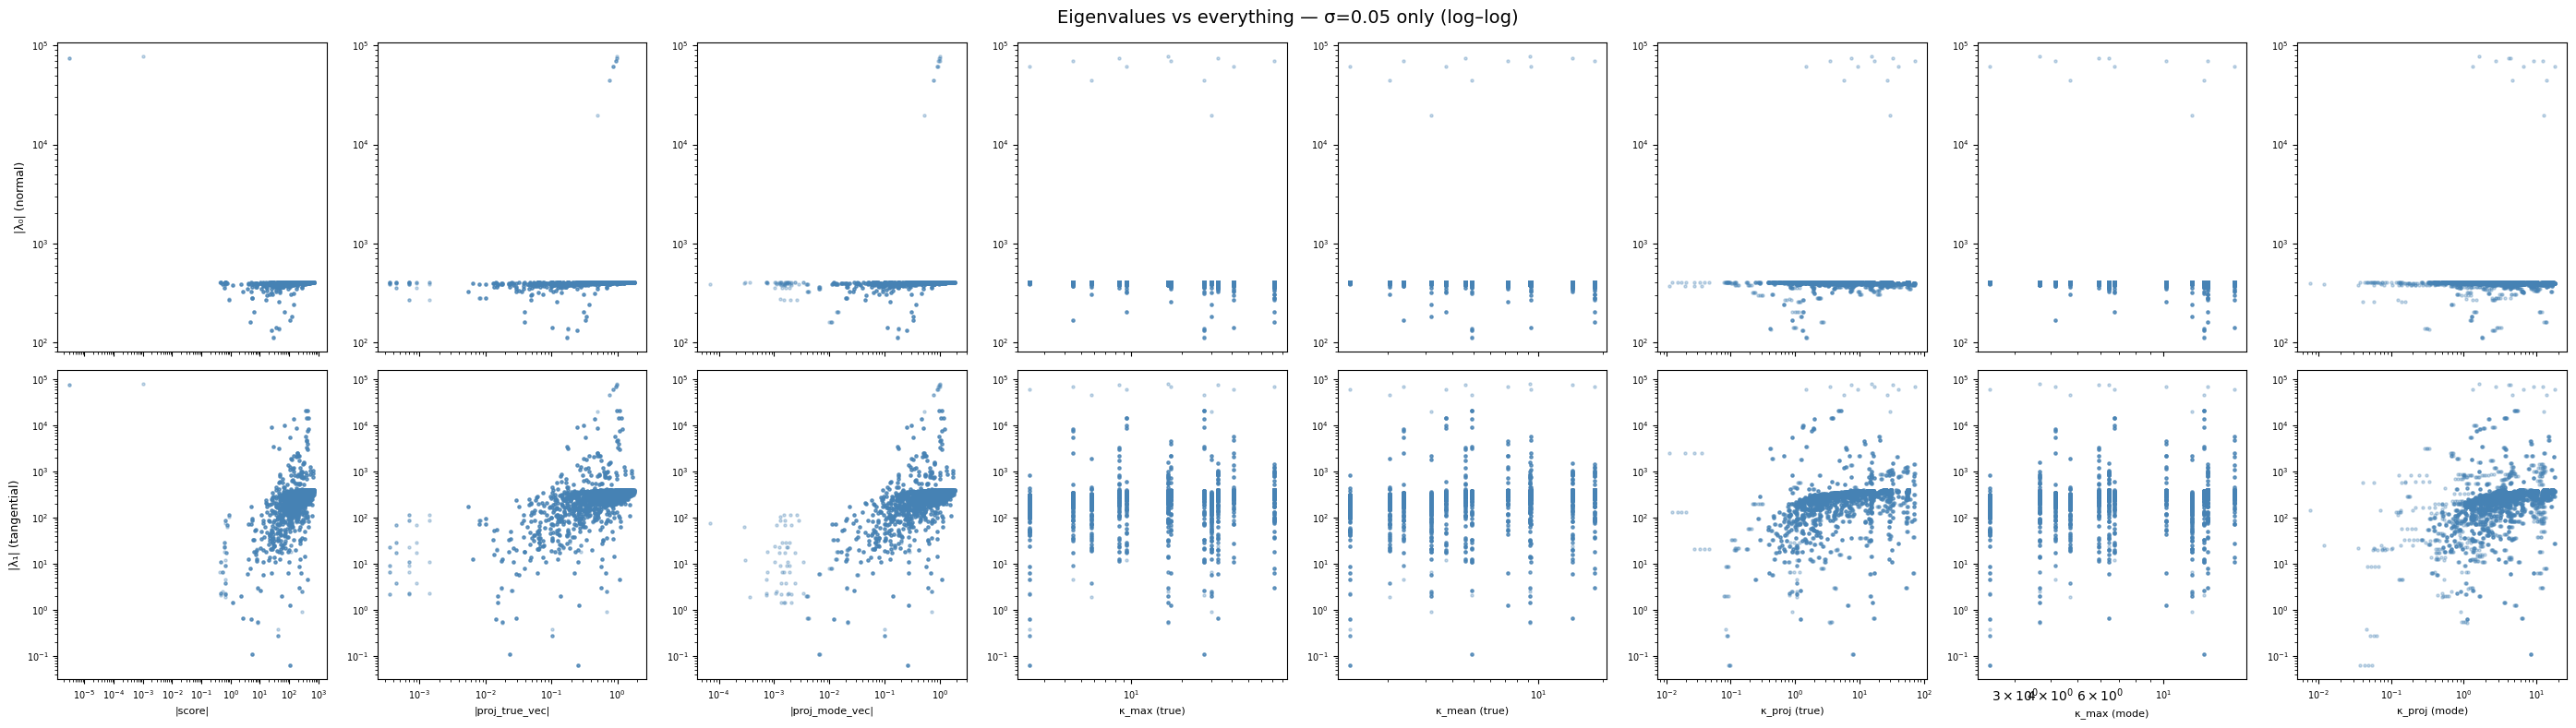

saved plots/10-eigenvalues-vs-all-sigma005.png


In [ ]:
vsub = v[v['sigma'] == 0.05].copy()
vsub = vsub[(vsub['abs_eig0'] > 1e-10) | (vsub['abs_eig1'] > 1e-10)]

fig, axes = plt.subplots(2, 8, figsize=(28, 8), sharex='col')
fig.suptitle('Eigenvalues vs everything — σ=0.05 only (log–log)', fontsize=14)

for row, (ycol, ylabel) in enumerate(y_rows):
    for col, (xcol, xlabel) in enumerate(x_cols):
        ax = axes[row, col]
        sub = vsub[(vsub[xcol] > 1e-10) & (vsub[ycol] > 1e-10)]
        ax.scatter(sub[xcol], sub[ycol], s=5, alpha=0.3,
                   color='steelblue', rasterized=True)
        ax.set_xscale('log')
        ax.set_yscale('log')
        if row == 1:
            ax.set_xlabel(xlabel, fontsize=8)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('plots/10-eigenvalues-vs-all-sigma005.png', dpi=110, bbox_inches='tight')
plt.show()
print("saved plots/10-eigenvalues-vs-all-sigma005.png")


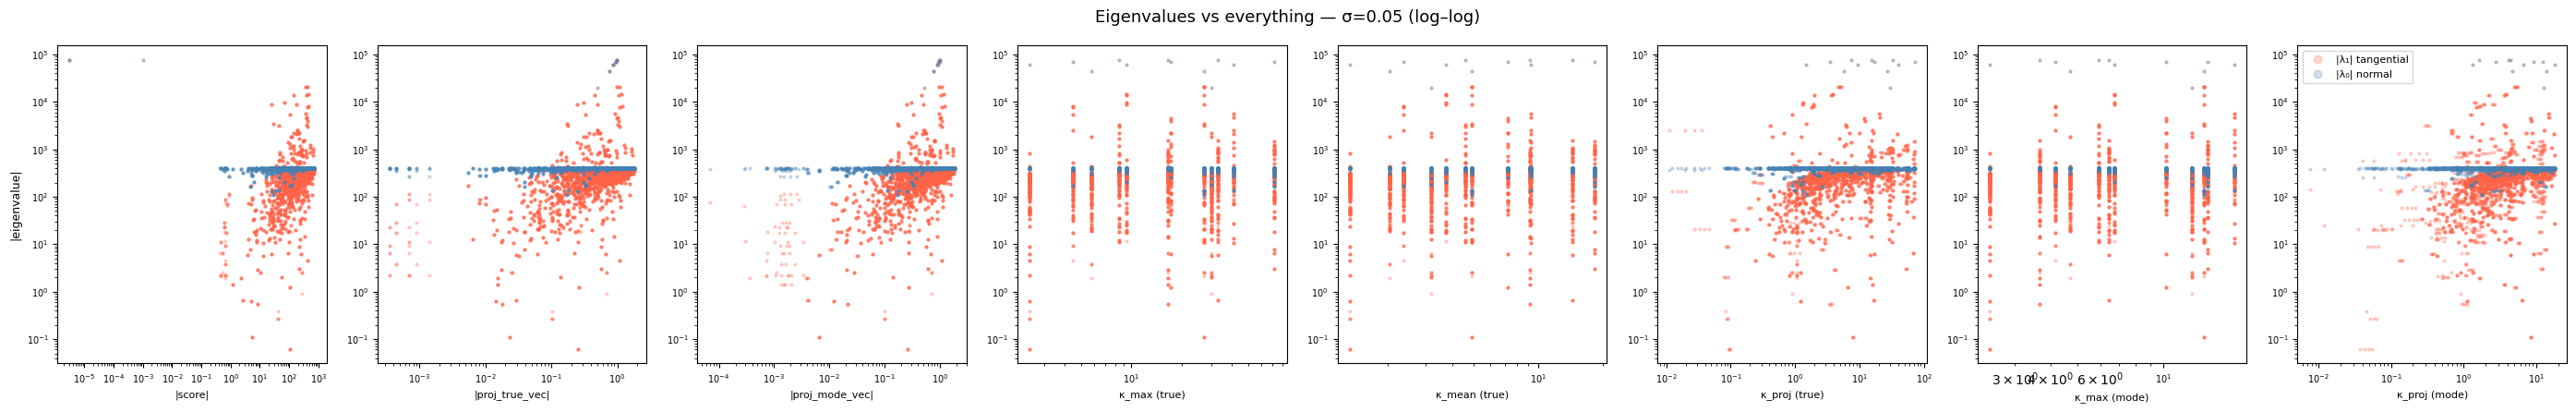

In [ ]:
vsub = v[v['sigma'] == 0.05].copy()

fig, axes = plt.subplots(1, 8, figsize=(28, 4.5))
fig.suptitle('Eigenvalues vs everything — σ=0.05 (log–log)', fontsize=13)

for col, (xcol, xlabel) in enumerate(x_cols):
    ax = axes[col]
    for ycol, label, color in [('abs_eig1', '|λ₁| tangential', 'tomato'),
                                ('abs_eig0', '|λ₀| normal', 'steelblue')]:
        sub = vsub[(vsub[xcol] > 1e-10) & (vsub[ycol] > 1e-10)]
        ax.scatter(sub[xcol], sub[ycol], s=4, alpha=0.25,
                   color=color, label=label, rasterized=True)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=8)
    if col == 0:
        ax.set_ylabel('|eigenvalue|', fontsize=9)
    ax.tick_params(labelsize=7)

axes[-1].legend(fontsize=8, markerscale=3, loc='upper left')

plt.tight_layout()
plt.savefig('plots/10-eigenvalues-merged-sigma005.png', dpi=110, bbox_inches='tight')
plt.show()


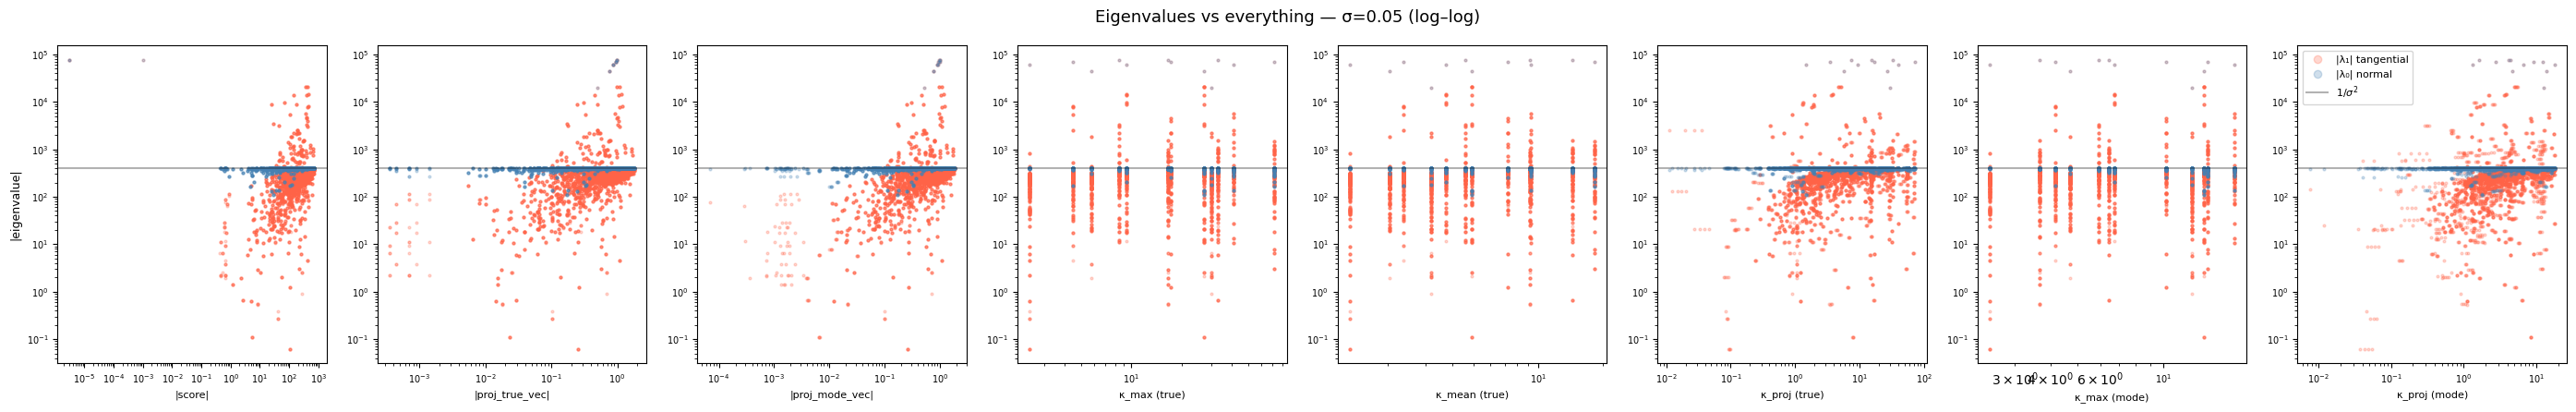

In [ ]:
vsub = v[v['sigma'] == 0.05].copy()
sigma_ref = 0.05

fig, axes = plt.subplots(1, 8, figsize=(28, 4.5))
fig.suptitle('Eigenvalues vs everything — σ=0.05 (log–log)', fontsize=13)

for col, (xcol, xlabel) in enumerate(x_cols):
    ax = axes[col]
    for ycol, label, color in [('abs_eig1', '|λ₁| tangential', 'tomato'),
                                ('abs_eig0', '|λ₀| normal', 'steelblue')]:
        sub = vsub[(vsub[xcol] > 1e-10) & (vsub[ycol] > 1e-10)]
        ax.scatter(sub[xcol], sub[ycol], s=4, alpha=0.25,
                   color=color, label=label, rasterized=True)
    ax.axhline(1 / sigma_ref**2, color='black', alpha=0.3, lw=1.5,
               label=r'$1/\sigma^2$' if col == 0 else None)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=8)
    if col == 0:
        ax.set_ylabel('|eigenvalue|', fontsize=9)
    ax.tick_params(labelsize=7)

handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles=handles, labels=labels, fontsize=8, markerscale=3, loc='upper left')

plt.tight_layout()
plt.savefig('plots/10-eigenvalues-merged-sigma005.png', dpi=110, bbox_inches='tight')
plt.show()


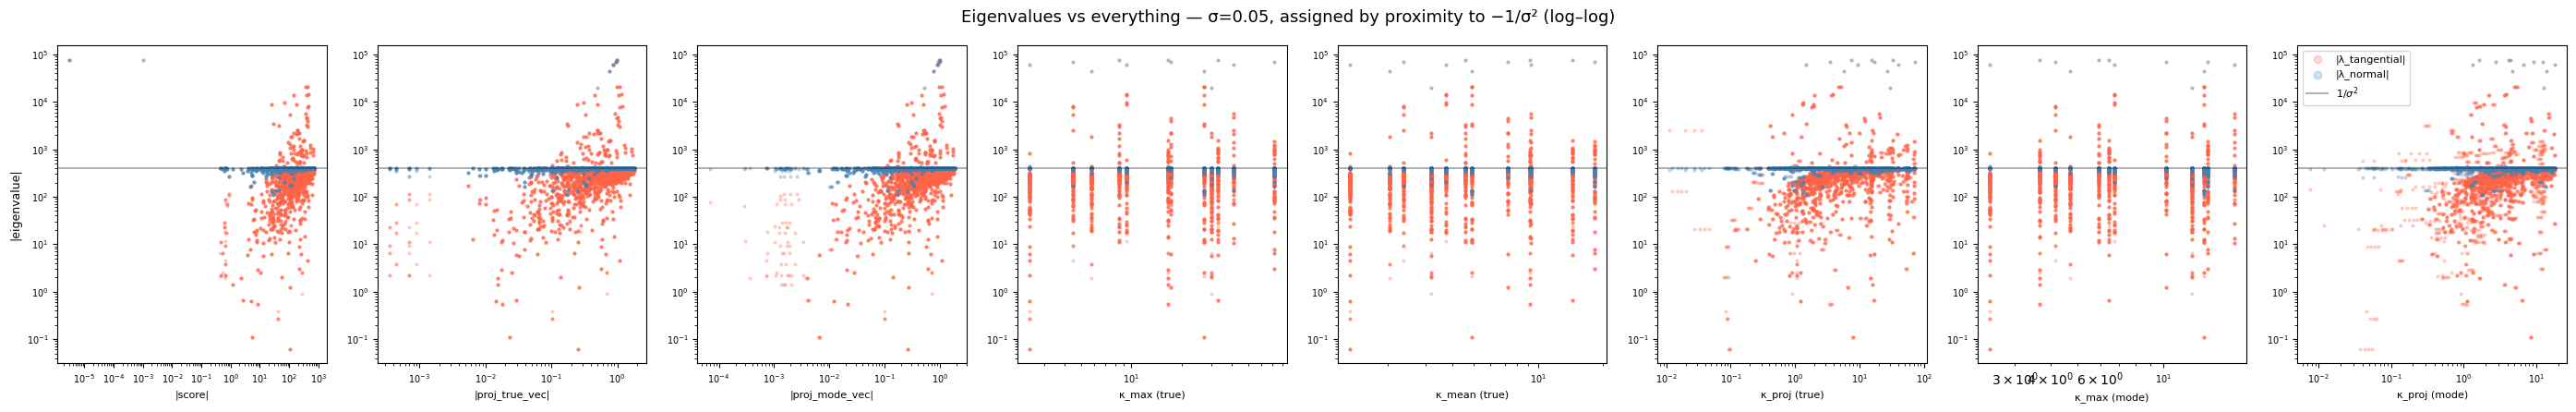

In [ ]:
vsub = v[v['sigma'] == 0.05].copy()
sigma_ref = 0.05
ref = -1 / sigma_ref**2  # -400

# per-row: which eigval is closer to ref?
d0 = (vsub['eigval_0'] - ref).abs()
d1 = (vsub['eigval_1'] - ref).abs()
eig0_is_normal = d0 <= d1

vsub['eig_normal']     = np.where(eig0_is_normal, vsub['eigval_0'], vsub['eigval_1'])
vsub['eig_tangential'] = np.where(eig0_is_normal, vsub['eigval_1'], vsub['eigval_0'])
vsub['abs_eig_normal']     = vsub['eig_normal'].abs()
vsub['abs_eig_tangential'] = vsub['eig_tangential'].abs()

swapped = (~eig0_is_normal).sum()
print(f"Rows where assignment flipped vs ordering: {swapped} / {len(vsub)}")

fig, axes = plt.subplots(1, 8, figsize=(28, 4.5))
fig.suptitle('Eigenvalues vs everything — σ=0.05, assigned by proximity to −1/σ² (log–log)', fontsize=13)

for col, (xcol, xlabel) in enumerate(x_cols):
    ax = axes[col]
    for ycol, label, color in [('abs_eig_tangential', '|λ_tangential|', 'tomato'),
                                ('abs_eig_normal',     '|λ_normal|',     'steelblue')]:
        sub = vsub[(vsub[xcol] > 1e-10) & (vsub[ycol] > 1e-10)]
        ax.scatter(sub[xcol], sub[ycol], s=4, alpha=0.25,
                   color=color, label=label, rasterized=True)
    ax.axhline(1 / sigma_ref**2, color='black', alpha=0.3, lw=1.5,
               label=r'$1/\sigma^2$' if col == 0 else None)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=8)
    if col == 0:
        ax.set_ylabel('|eigenvalue|', fontsize=9)
    ax.tick_params(labelsize=7)

handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles=handles, labels=labels, fontsize=8, markerscale=3, loc='upper left')

plt.tight_layout()
plt.savefig('plots/10-eigenvalues-assigned-sigma005.png', dpi=110, bbox_inches='tight')
plt.show()


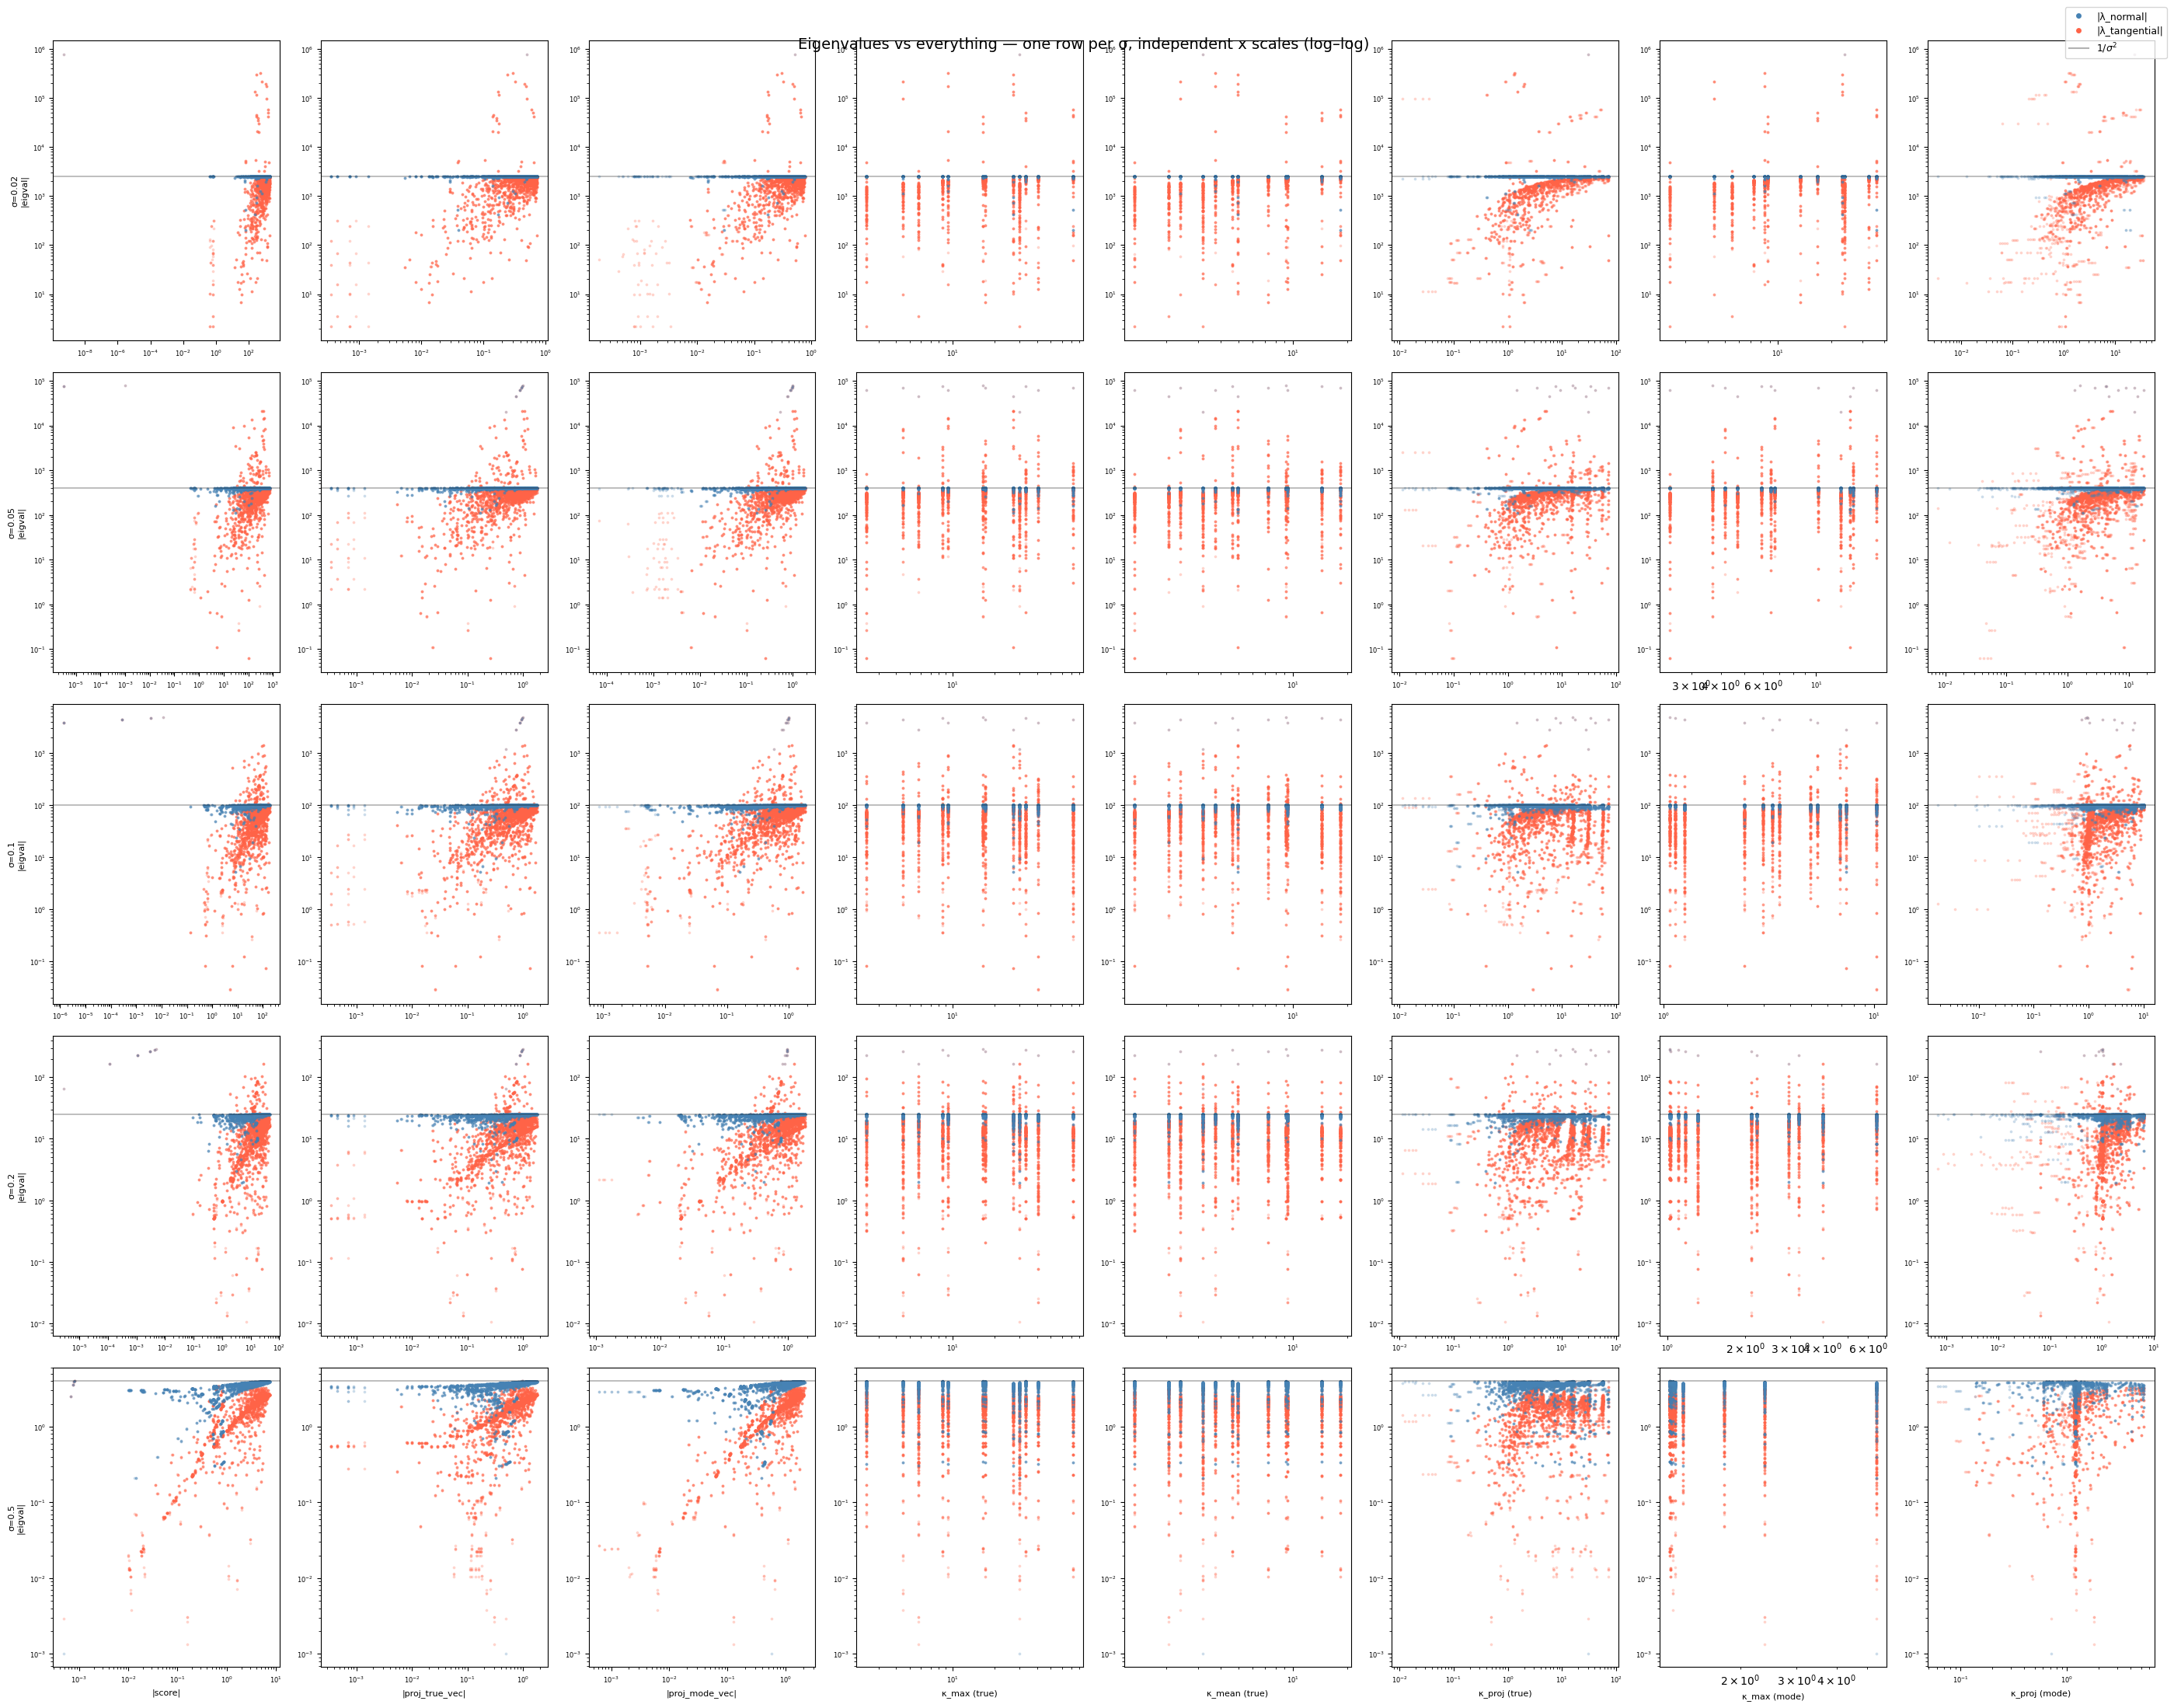

saved plots/10-eigenvalues-per-sigma-freex.png


In [ ]:
fig, axes = plt.subplots(5, 8, figsize=(28, 22))  # no sharex
fig.suptitle('Eigenvalues vs everything — one row per σ, independent x scales (log–log)', fontsize=14)

for row, sig in enumerate(sigmas):
    vsig = v[v['sigma'] == sig].copy()
    ref = -1 / sig**2

    d0 = (vsig['eigval_0'] - ref).abs()
    d1 = (vsig['eigval_1'] - ref).abs()
    eig0_is_normal = d0 <= d1
    vsig['abs_eig_normal']     = np.where(eig0_is_normal, vsig['eigval_0'], vsig['eigval_1'])
    vsig['abs_eig_tangential'] = np.where(eig0_is_normal, vsig['eigval_1'], vsig['eigval_0'])
    vsig['abs_eig_normal']     = vsig['abs_eig_normal'].abs()
    vsig['abs_eig_tangential'] = vsig['abs_eig_tangential'].abs()

    for col, (xcol, xlabel) in enumerate(x_cols):
        ax = axes[row, col]
        for ycol, label, color in [('abs_eig_tangential', '|λ_tan|', 'tomato'),
                                    ('abs_eig_normal',     '|λ_norm|', 'steelblue')]:
            sub = vsig[(vsig[xcol] > 1e-10) & (vsig[ycol] > 1e-10)]
            ax.scatter(sub[xcol], sub[ycol], s=3, alpha=0.2,
                       color=color, label=label, rasterized=True)
        ax.axhline(1 / sig**2, color='black', alpha=0.3, lw=1.2)
        ax.set_xscale('log')
        ax.set_yscale('log')
        if row == 4:
            ax.set_xlabel(xlabel, fontsize=8)
        if col == 0:
            ax.set_ylabel(f'σ={sig}\n|eigval|', fontsize=8)
        ax.tick_params(labelsize=6)

handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=6, label='|λ_normal|'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',    markersize=6, label='|λ_tangential|'),
    Line2D([0],[0], color='black', alpha=0.3, lw=1.5, label=r'$1/\sigma^2$'),
]
fig.legend(handles=handles, fontsize=9, loc='upper right', bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.savefig('plots/10-eigenvalues-per-sigma-freex.png', dpi=100, bbox_inches='tight')
plt.show()
print("saved plots/10-eigenvalues-per-sigma-freex.png")


# Score vector vs projection vectors

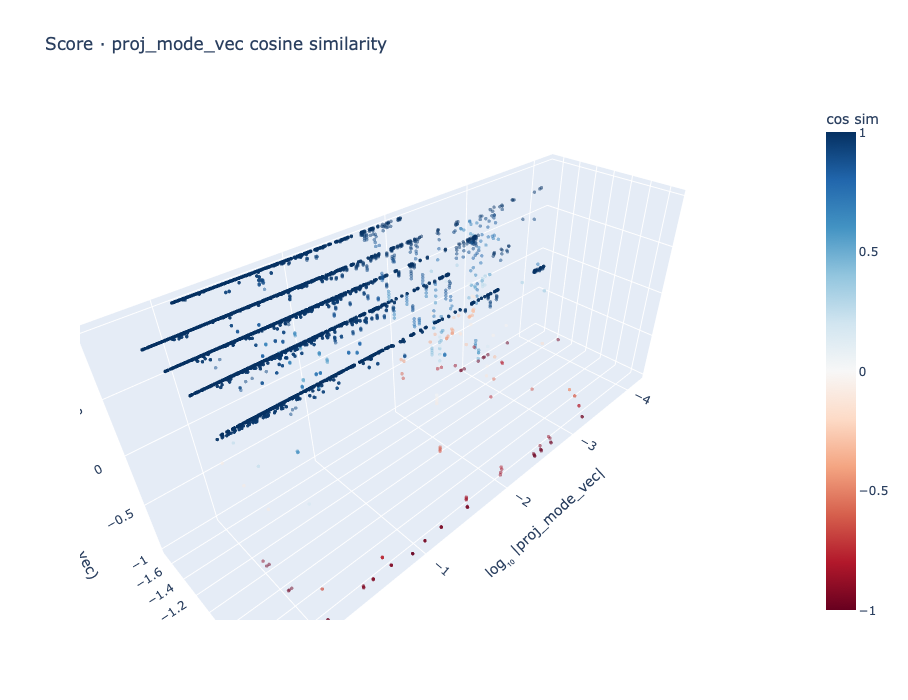

In [ ]:
import plotly.graph_objects as go

v3 = df.dropna(subset=['score_x']).copy()
v3['score_mag']     = np.sqrt(v3['score_x']**2 + v3['score_y']**2)
v3['proj_mode_mag'] = np.sqrt(v3['proj_mode_vec_x']**2 + v3['proj_mode_vec_y']**2)

sv  = v3[['score_x', 'score_y']].values
pv  = v3[['proj_mode_vec_x', 'proj_mode_vec_y']].values
denom = (v3['score_mag'] * v3['proj_mode_mag']).clip(1e-12)
v3['cos_mode'] = (sv * pv).sum(axis=1) / denom.values

# drop near-zero mags (undefined cosine)
v3 = v3[(v3['score_mag'] > 1e-8) & (v3['proj_mode_mag'] > 1e-8)]

fig = go.Figure(go.Scatter3d(
    x=np.log10(v3['proj_mode_mag']),
    y=np.log10(v3['sigma']),
    z=v3['cos_mode'],
    mode='markers',
    marker=dict(
        size=2,
        color=v3['cos_mode'],
        colorscale='RdBu',
        cmid=0,
        colorbar=dict(title='cos sim'),
        opacity=0.5,
    ),
    text=[f"σ={s:.2f}, |proj|={p:.4f}, cos={c:.3f}"
          for s, p, c in zip(v3['sigma'], v3['proj_mode_mag'], v3['cos_mode'])],
    hoverinfo='text',
))

fig.update_layout(
    title='Score · proj_mode_vec cosine similarity',
    scene=dict(
        xaxis_title='log₁₀ |proj_mode_vec|',
        yaxis_title='log₁₀ σ',
        zaxis_title='cos(score, proj_mode_vec)',
        zaxis=dict(range=[-1.05, 1.05]),
    ),
    width=900, height=700,
)

fig.show()


In [20]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import VBox, HBox
from scipy.ndimage import gaussian_filter1d


# ── helpers ────────────────────────────────────────────────────────────────

def _sin_manifold(k, A, nx=2000):
    """True curve y = A sin(k π x), x ∈ [-2, 2), periodic in x.
    Returns (xc, yc, ds) where ds = ||tangent|| * (period/nx) is the arc-length
    element at each sample point, so that sum(f * ds) ≈ ∫ f ds.
    """
    x = np.linspace(-2, 2, nx, endpoint=False)
    y = A * np.sin(k * np.pi * x)
    dydx = A * k * np.pi * np.cos(k * np.pi * x)
    dx = 4.0 / nx  # uniform x-spacing
    ds = np.sqrt(1.0 + dydx**2) * dx
    return x, y, ds


def _score_and_jacobian_cyl(x0, y0, xc, yc, ds, sigma, period=4.0):
    """Score ∇ log p_σ and Hessian eigendecomp at (x0, y0) on the cylinder.
    Weights each curve sample by its arc-length element ds so the prior on
    the curve is uniform w.r.t. arc length.
    """
    dx = xc - x0
    dx = dx - period * np.round(dx / period)   # shortest-path wrap
    dist_sq = dx**2 + (yc - y0)**2

    log_w = -dist_sq / (2 * sigma**2)
    log_w -= log_w.max()
    w = np.exp(log_w) * ds                     # arc-length weight
    w /= w.sum()

    mu = np.array([x0 + w @ dx, w @ yc])
    score = (mu - np.array([x0, y0])) / sigma**2

    # covariance in shifted frame
    mu_shifted = np.array([w @ dx, w @ yc - y0])
    E_sq = np.array([[w @ (dx**2),           w @ (dx * (yc - y0))],
                     [w @ (dx * (yc - y0)),  w @ ((yc - y0)**2)  ]])
    cov = E_sq - np.outer(mu_shifted, mu_shifted)
    J = cov / sigma**4 - np.eye(2) / sigma**2

    eigvals, eigvecs = np.linalg.eigh(J)
    return score, eigvecs, eigvals


def _mode_curve_cyl(k, A, sigma, period=4.0, nx=2000, nr=500):
    """Mode curve of p_σ on the cylinder, density weighted by arc length."""
    xc, yc, ds = _sin_manifold(k, A, nx=nx)

    x_grid = np.linspace(-2, 2, nx, endpoint=False)
    y_span = np.linspace(-2, 2, nr)

    density = np.zeros((nr, nx))
    for i in range(nr):
        dx = xc[np.newaxis, :] - x_grid[:, np.newaxis]   # (nx, nx_c)
        dx_w = dx - period * np.round(dx / period)
        dist_sq = dx_w**2 + (yc[np.newaxis, :] - y_span[i])**2
        density[i] = (np.exp(-dist_sq / (2 * sigma**2)) * ds).sum(axis=1)

    idx_c = np.clip(np.argmax(density, axis=0), 1, nr - 2)
    j = np.arange(nx)
    f0, f1, f2 = density[idx_c - 1, j], density[idx_c, j], density[idx_c + 1, j]
    denom = f0 - 2 * f1 + f2
    offset = np.where(np.abs(denom) > 1e-30, 0.5 * (f0 - f2) / denom, 0.0)
    y_mode = y_span[idx_c] + offset * (y_span[1] - y_span[0])
    y_mode = gaussian_filter1d(y_mode, sigma=nx / 200, mode='wrap')
    return x_grid, y_mode


# ── interactive plot ────────────────────────────────────────────────────────

state = {'x': 0.3, 'y': 0.5}

k_slider     = widgets.IntSlider(  value=3,    min=1,    max=10,  step=1,    description='k')
A_slider     = widgets.FloatSlider(value=0.5,  min=0.0,  max=1.5, step=0.05, description='A')
sigma_slider = widgets.FloatSlider(value=0.15, min=0.01, max=0.7, step=0.01, description='σ')

fig2, ax2 = plt.subplots(figsize=(10, 5))
fig2.canvas.toolbar_visible = False


def redraw_sin():
    k     = k_slider.value
    A     = A_slider.value
    sigma = sigma_slider.value
    x0, y0 = state['x'], state['y']

    xc, yc, ds = _sin_manifold(k, A)
    x_mode, y_mode = _mode_curve_cyl(k, A, sigma)
    score, eigvecs, eigvals = _score_and_jacobian_cyl(x0, y0, xc, yc, ds, sigma)

    score_mag = np.linalg.norm(score)
    score_unit = score / score_mag if score_mag > 1e-9 else score

    for i in range(eigvecs.shape[1]):
        if np.dot(eigvecs[:, i], score_unit) < 0:
            eigvecs[:, i] *= -1

    ax2.cla()

    # density heatmap — weighted by arc-length element ds
    nx_h, ny_h = 300, 150
    xh = np.linspace(-2, 2, nx_h, endpoint=False)
    yh = np.linspace(-2, 2, ny_h)
    D = np.zeros((ny_h, nx_h))
    for i in range(ny_h):
        dx = xc[np.newaxis, :] - xh[:, np.newaxis]
        dx_w = dx - 4.0 * np.round(dx / 4.0)
        dist_sq = dx_w**2 + (yc[np.newaxis, :] - yh[i])**2
        D[i] = (np.exp(-dist_sq / (2 * sigma**2)) * ds).sum(axis=1)

    ax2.pcolormesh(xh, yh, D, shading='auto', cmap='viridis', alpha=0.55)
    ax2.plot(xc, yc, color='black', linewidth=1.5, label='True curve $C$')
    ax2.plot(xc, yc * np.exp(-sigma**2 / 2), color='white', linewidth=1.5,
             linestyle='--', label=r'$e^{-\sigma^2/2} C$')
    ax2.plot(x_mode, y_mode, color='red', linewidth=2.0, label='Mode curve $M_\\sigma$')

    L = 0.25
    ax2.quiver(x0, y0, score_unit[0], score_unit[1], color='white',
               scale=1/L, scale_units='xy', label='Score dir', zorder=5)
    ax2.quiver(x0, y0, eigvecs[0, 0], eigvecs[1, 0], color='cyan', alpha=0.7,
               scale=1/L, scale_units='xy', label=f'v₁ (λ={eigvals[0]:.2f})', zorder=4)
    ax2.quiver(x0, y0, eigvecs[0, 1], eigvecs[1, 1], color='magenta', alpha=0.7,
               scale=1/L, scale_units='xy', label=f'v₂ (λ={eigvals[1]:.2f})', zorder=4)
    ax2.scatter(x0, y0, color='orange', s=60, zorder=6)

    ax2.set_xlim(-2, 2)
    ax2.set_ylim(-2, 2)
    ax2.set_aspect('equal')
    ax2.set_xlabel('x  (periodic)')
    ax2.set_ylabel('y')
    ax2.set_title(
        rf'$y = A\sin(k\pi x)$, $k={k}$, $A={A:.2f}$, $\sigma={sigma:.2f}$'
        f'\nScore mag: {score_mag:.3f}  |  λ₁={eigvals[0]:.3f}, λ₂={eigvals[1]:.3f}'
    )
    ax2.legend(loc='upper right', fontsize=8, frameon=True)
    fig2.canvas.draw_idle()


def on_click2(event):
    if event.inaxes == ax2:
        state['x'], state['y'] = event.xdata, event.ydata
        redraw_sin()

fig2.canvas.mpl_connect('button_press_event', on_click2)

for sl in [k_slider, A_slider, sigma_slider]:
    sl.observe(lambda _: redraw_sin(), names='value')

display(VBox([HBox([k_slider, A_slider, sigma_slider]), fig2.canvas]))
redraw_sin()
